In [1]:
import os, sys, json
import polars as pl
import numpy as np
from db_robust_clust.plots import clustering_MDS_plot_multiple_methods
import seaborn as sns
sns.set_style('whitegrid')

In [2]:
project_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')) 
sys.path.append(project_path)

from src.utils.experiments_exploration_utils import process_experiment_5_results, plot_experiment_5_results, fast_mds
from src.utils.simulations_utils import generate_simulation
from config.config_simulations import SIMULATION_CONFIGS
from config.config_experiment_5 import (
    CONFIG_EXPERIMENT, 
    #NOT_FEASIBLE_METHODS, 
    N_REALIZATIONS, 
    PROP_ERRORS_THRESHOLD, 
    RANDOM_STATE_MDS,
    ADDITIONAL_METHODS_MDS
)

In [6]:
DATA_IDS = list(CONFIG_EXPERIMENT.keys())

raw_results, df_avg_results, not_feasible_methods_results = {}, {}, {}

for data_id in DATA_IDS:

    results_dir = os.path.join(project_path, 'results', 'experiment_5', data_id)
    filename = f'results_exp_5_{data_id}.pkl'
    results_path = os.path.join(results_dir, filename)
    
    if 'simulation' in data_id:
        simulation_config = SIMULATION_CONFIGS[data_id]
    config_experiment = CONFIG_EXPERIMENT[data_id]
    #not_feasible_methods_to_add = NOT_FEASIBLE_METHODS[data_id]

    df, df_avg, not_feasible_methods, results = process_experiment_5_results(
        results_path=results_path, 
        #not_feasible_methods_to_add=not_feasible_methods_to_add,
        prop_errors_threshold=PROP_ERRORS_THRESHOLD,
        verbose=False
    )

    # df_avg = df_avg.with_columns(
    #     pl.col('model_name').replace({'KMedoids-euclidean': 'KMedoids-pam'})
    # )
    
    raw_results[data_id] = results.copy()
    df_avg_results[data_id] = df_avg.clone()
    not_feasible_methods_results[data_id] = not_feasible_methods
    
    print('-'*50)
    print(data_id.upper())
    print('-'*50)
    display(df_avg)

--------------------------------------------------
SIMULATION_BASE
--------------------------------------------------


model_name,mean_ari,mean_adj_accuracy,mean_time,std_ari,std_adj_accuracy,std_time,prop_status_error
str,f64,f64,f64,f64,f64,f64,f64
"""LDAKmeans""",0.975707,0.991565,0.143658,0.037693,0.013565,0.073862,0.0
"""AgglomerativeClustering""",0.958265,0.984872,2.042846,0.06321,0.024657,0.133425,0.0
"""Birch""",0.95491,0.983702,2.022754,0.065081,0.024804,0.228396,0.0
"""KMedoids-fastpam""",0.952461,0.983078,5.407941,0.058846,0.022114,0.75391,0.0
"""KMedoids-pam""",0.952461,0.983078,8.351408,0.058846,0.022114,1.638773,0.0
…,…,…,…,…,…,…,…
"""FastKmedoidsGGower-robust_maha…",0.641309,0.841597,1.715286,0.194451,0.108447,0.174337,0.0
"""FastKmedoidsGGower-robust_maha…",0.640342,0.840095,1.749212,0.202008,0.112111,0.178924,0.0
"""FoldFastKmedoidsGGower-robust_…",0.620445,0.834194,1.726564,0.197902,0.106817,0.179632,0.0


--------------------------------------------------
DUBAI_HOUSES
--------------------------------------------------


model_name,mean_ari,mean_adj_accuracy,mean_time,std_ari,std_adj_accuracy,std_time,prop_status_error
str,f64,f64,f64,f64,f64,f64,f64
"""FastKmedoidsGGower-robust_maha…",0.507498,0.825181,0.867647,0.004056,0.001352,0.598861,0.0
"""FastKmedoidsGGower-robust_maha…",0.506913,0.825027,0.853813,0.004374,0.001417,0.54937,0.0
"""FastKmedoidsGGower-robust_maha…",0.503586,0.824259,0.831994,0.008897,0.00261,0.446279,0.0
"""FoldFastKmedoidsGGower-robust_…",0.495705,0.818116,5.208422,0.021516,0.013583,2.650942,0.0
"""FoldFastKmedoidsGGower-robust_…",0.493382,0.81676,3.738371,0.036481,0.023778,1.266072,0.0
…,…,…,…,…,…,…,…
"""CLARA""",-0.004902,0.505997,0.013721,0.007643,0.003809,0.006559,0.0
"""LDAKmeans""",-0.008881,0.505507,0.50571,0.0,0.0,0.155607,0.0
"""KMedoids-euclidean""",0.000912,0.501748,0.775343,0.0,0.0,0.216234,0.0


--------------------------------------------------
HEART_DISEASE
--------------------------------------------------


model_name,mean_ari,mean_adj_accuracy,mean_time,std_ari,std_adj_accuracy,std_time,prop_status_error
str,f64,f64,f64,f64,f64,f64,f64
"""FastKmedoidsGGower-robust_maha…",0.367619,0.803502,0.520695,0.042575,0.018308,0.073836,0.0
"""FastKmedoidsGGower-robust_maha…",0.366607,0.802997,0.543122,0.045683,0.019746,0.122164,0.0
"""FastKmedoidsGGower-robust_maha…",0.361187,0.800976,0.335902,0.03708,0.016044,0.064668,0.0
"""FastKmedoidsGGower-robust_maha…",0.261853,0.751684,0.514427,0.099923,0.052841,0.085482,0.0
"""FastKmedoidsGGower-robust_maha…",0.258329,0.75,0.542236,0.099897,0.052523,0.11923,0.0
…,…,…,…,…,…,…,…
"""Birch""",0.001792,0.538721,0.01604,0.0,0.0,0.001657,0.0
"""AgglomerativeClustering""",0.001792,0.538721,0.003187,0.0,0.0,0.00078,0.0
"""GaussianMixture""",-0.002124,0.525253,0.018311,0.0,0.0,0.009496,0.0


--------------------------------------------------
KC_HOUSES
--------------------------------------------------


model_name,mean_ari,mean_adj_accuracy,mean_time,std_ari,std_adj_accuracy,std_time,prop_status_error
str,f64,f64,f64,f64,f64,f64,f64
"""FastKmedoidsGGower-robust_maha…",0.024134,0.569883,5.251655,0.013047,0.032499,2.820551,0.0
"""FastKmedoidsGGower-robust_maha…",0.024134,0.569883,5.186053,0.013047,0.032499,2.46476,0.0
"""FastKmedoidsGGower-robust_maha…",0.024134,0.569883,5.121843,0.013047,0.032499,2.870223,0.0
"""FastKmedoidsGGower-robust_maha…",0.024134,0.569883,5.083181,0.013047,0.032499,2.434615,0.0
"""FastKmedoidsGGower-robust_maha…",0.024134,0.569883,5.174374,0.013047,0.032499,2.485323,0.0
…,…,…,…,…,…,…,…
"""BisectingKMeans""",0.000816,0.341309,0.02781,0.0,0.0,0.010749,0.0
"""AgglomerativeClustering""",-0.000182,0.340307,14.20747,0.0,0.0,4.820803,0.0
"""Diana""",0.001483,0.340178,9.84295,0.0,0.0,4.984466,0.0


--------------------------------------------------
SIMULATION_BASE
--------------------------------------------------


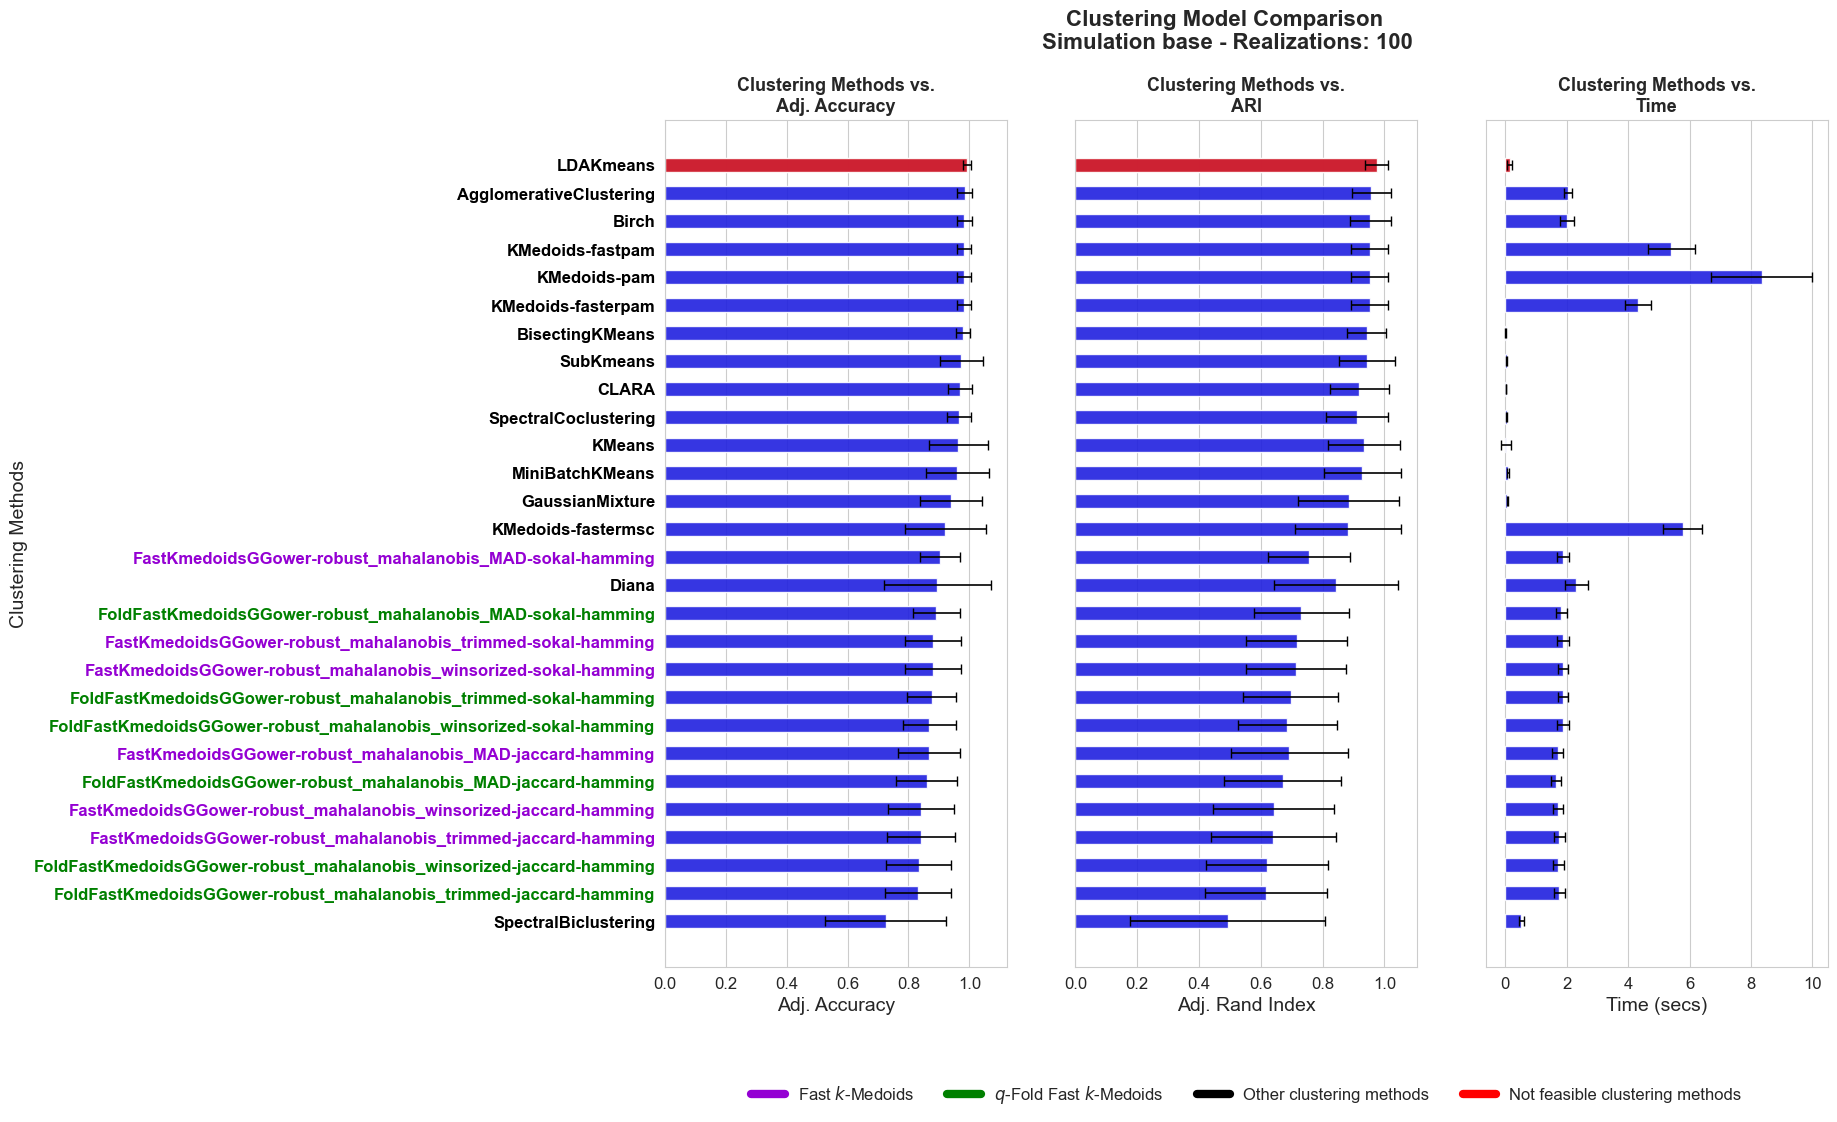

--------------------------------------------------
DUBAI_HOUSES
--------------------------------------------------


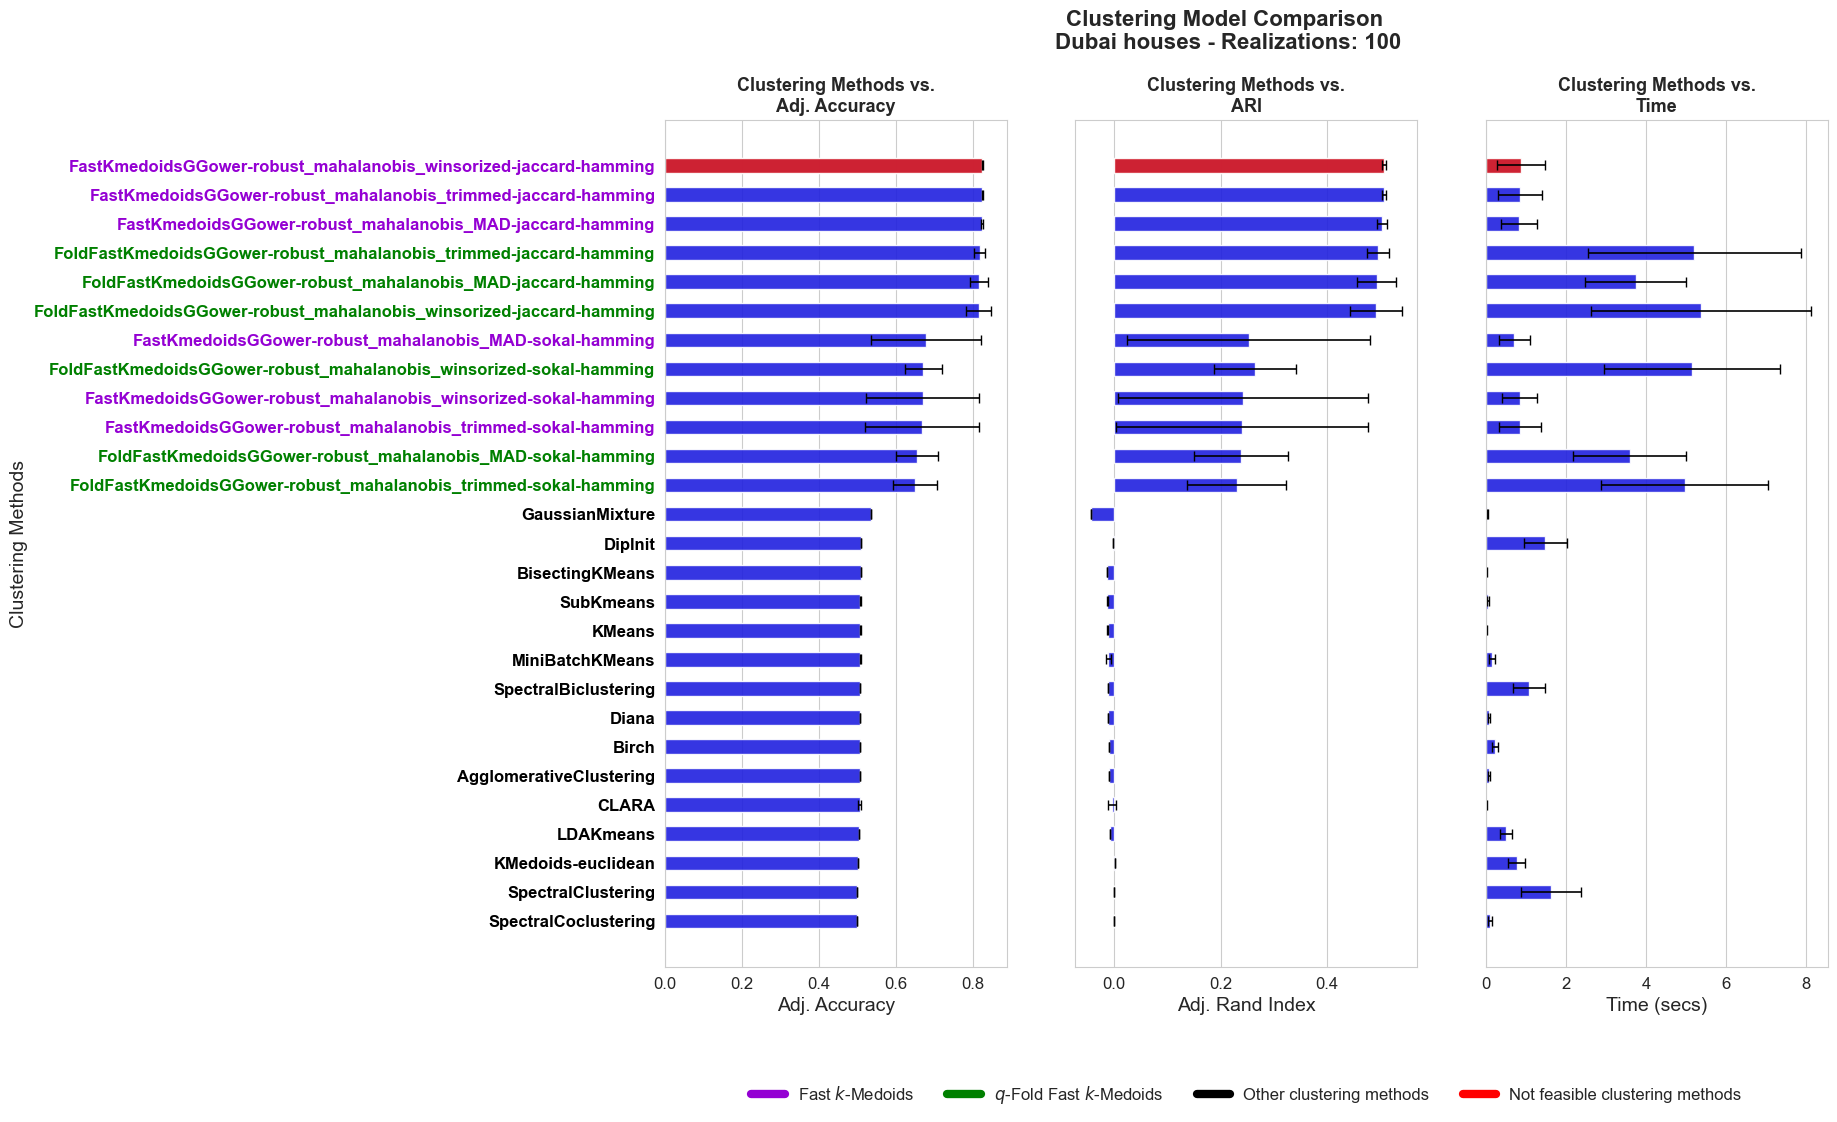

--------------------------------------------------
HEART_DISEASE
--------------------------------------------------


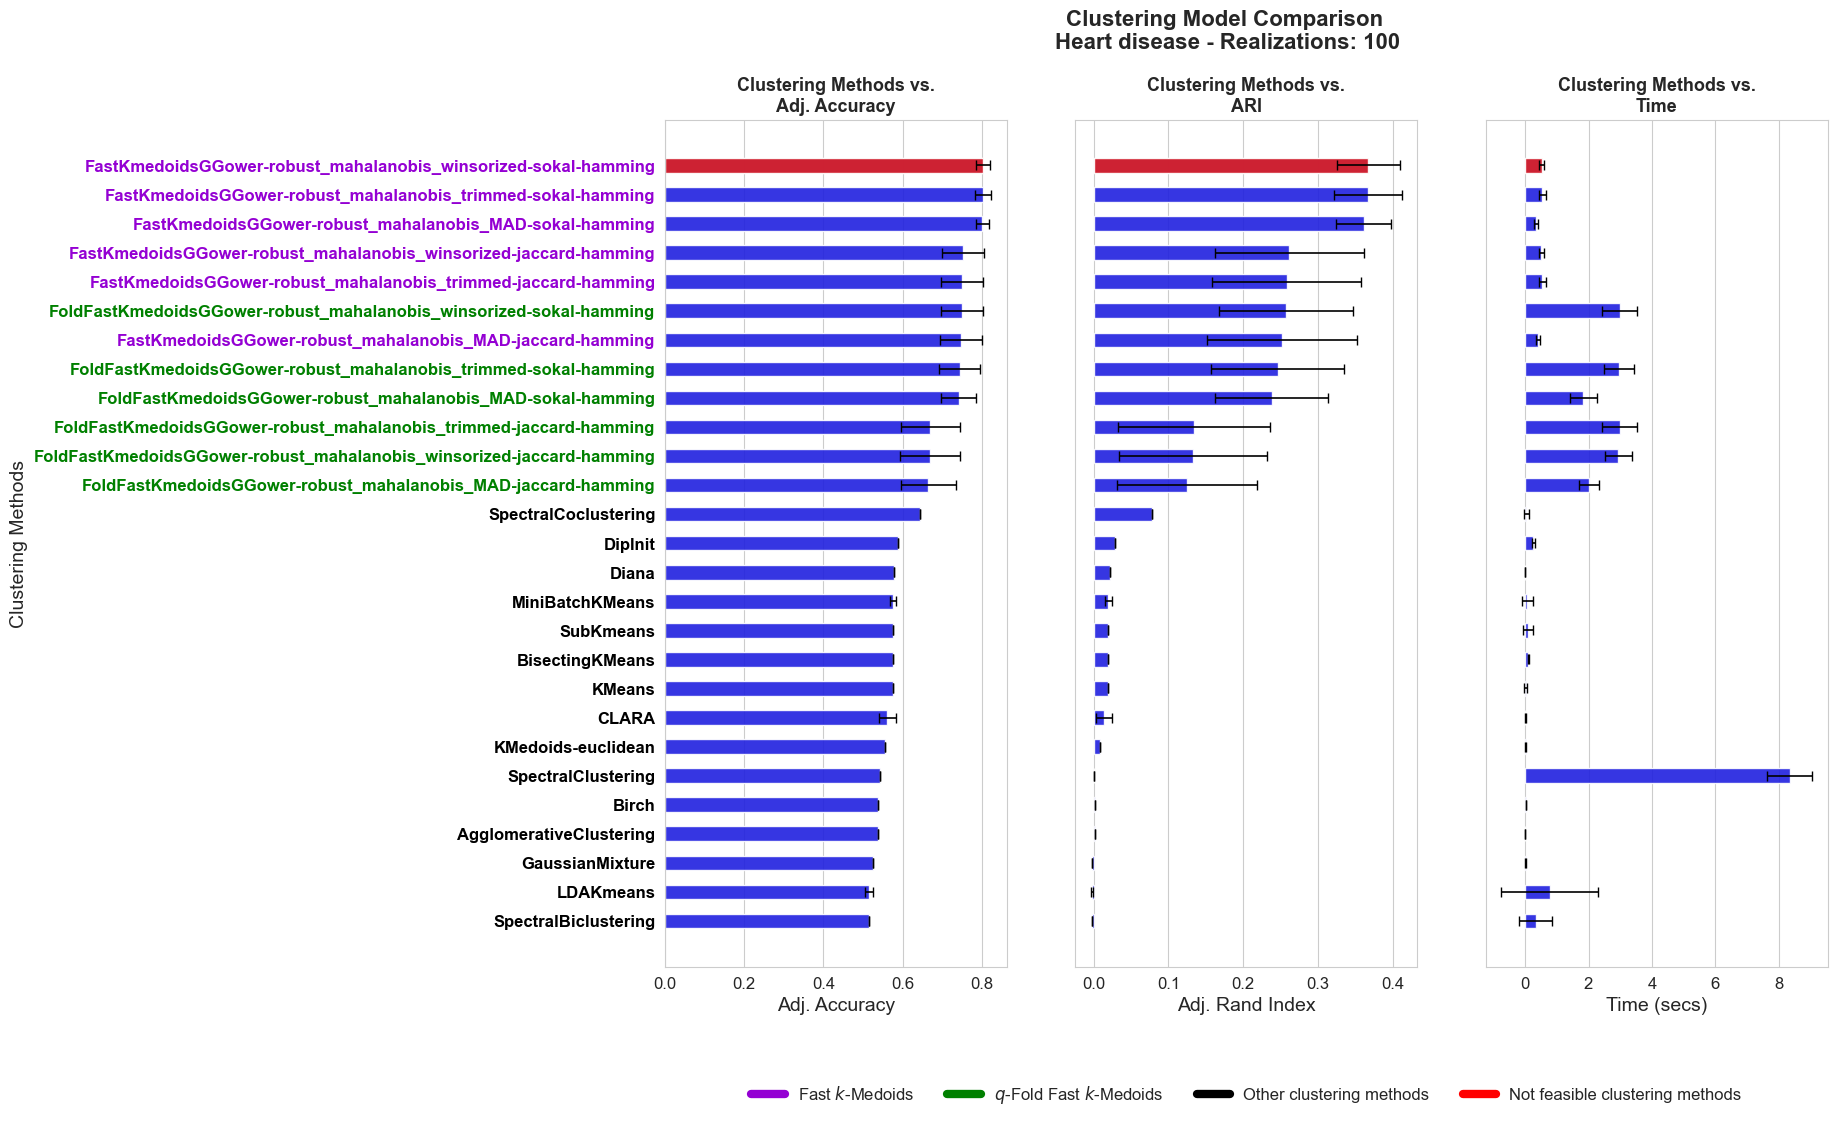

--------------------------------------------------
KC_HOUSES
--------------------------------------------------


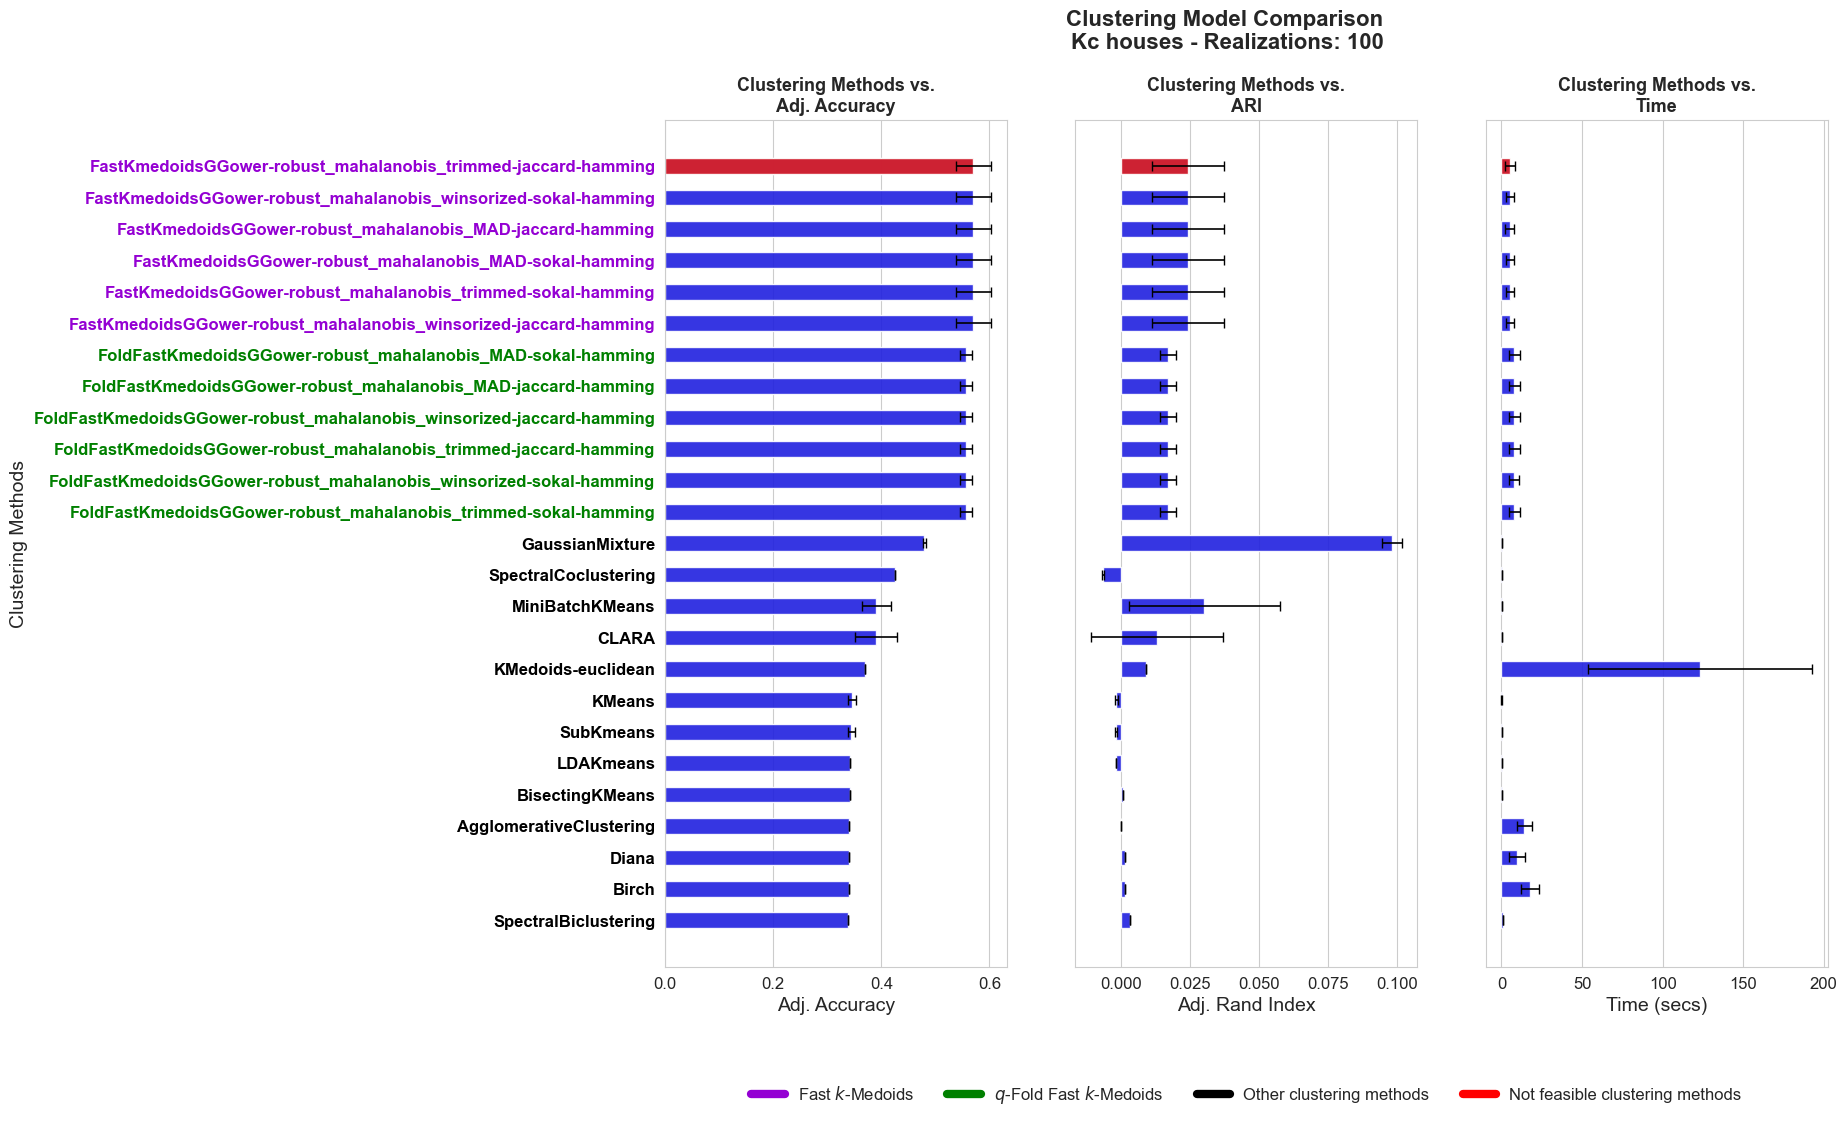

In [7]:
for data_id in DATA_IDS:
    
    not_feasible_methods = not_feasible_methods_results[data_id]
    model_names = df_avg_results[data_id]['model_name'].unique().to_list()
    our_methods_1 = [x for x in model_names if 'Fast' in x and 'Fold' not in x] # Fast k-medoids
    our_methods_2 = [x for x in model_names if 'Fast' in x and 'Fold' in x] # q-Fold Fast k-medoids
    other_methods = [x for x in model_names if x not in our_methods_1 + our_methods_2 and x not in not_feasible_methods]
    plot_filename = f'plot_results_exp_5_{data_id}.png'
    save_path = os.path.join(results_dir, plot_filename)

    print('-'*50)
    print(data_id.upper())
    print('-'*50)
    plot_experiment_5_results(
        df_avg = df_avg_results[data_id], 
        data_name = data_id, 
        num_realizations = N_REALIZATIONS, 
        save_path = save_path, 
        our_methods_1=our_methods_1, our_methods_2=our_methods_2, 
        other_methods=other_methods, not_feasible_methods=not_feasible_methods)

--------------------------------------------------
SIMULATION_SIZE_1
--------------------------------------------------


c:\Users\fscielzo\Documents\PhD\paper-2\paper-code\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


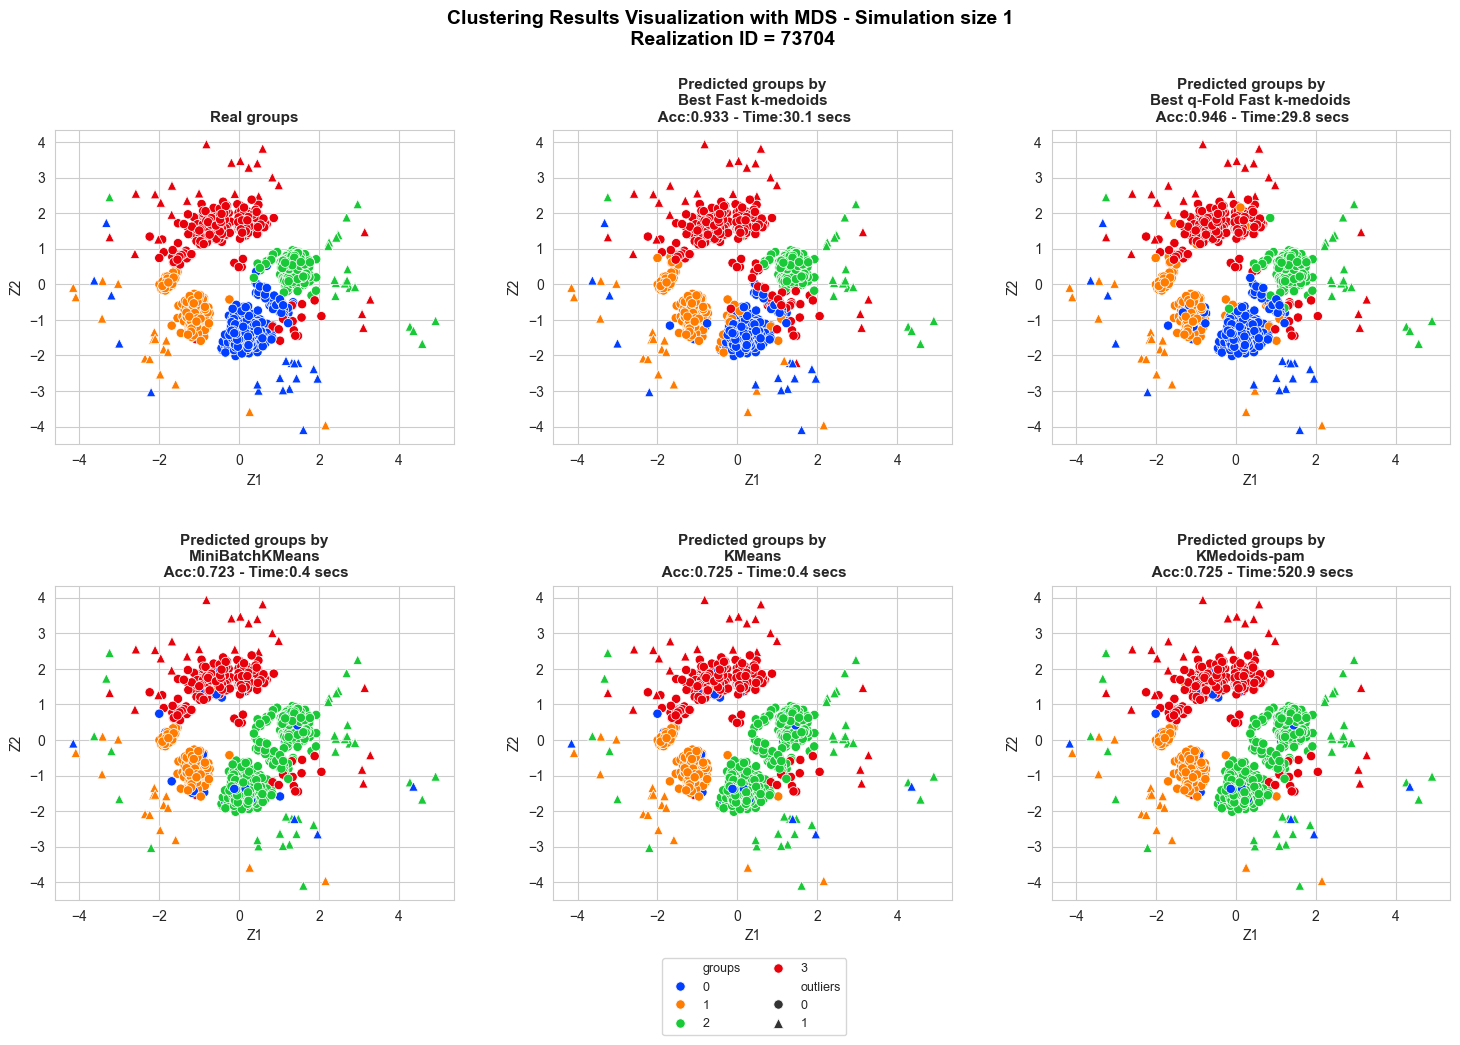

--------------------------------------------------
SIMULATION_SIZE_2
--------------------------------------------------


c:\Users\fscielzo\Documents\PhD\paper-2\paper-code\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


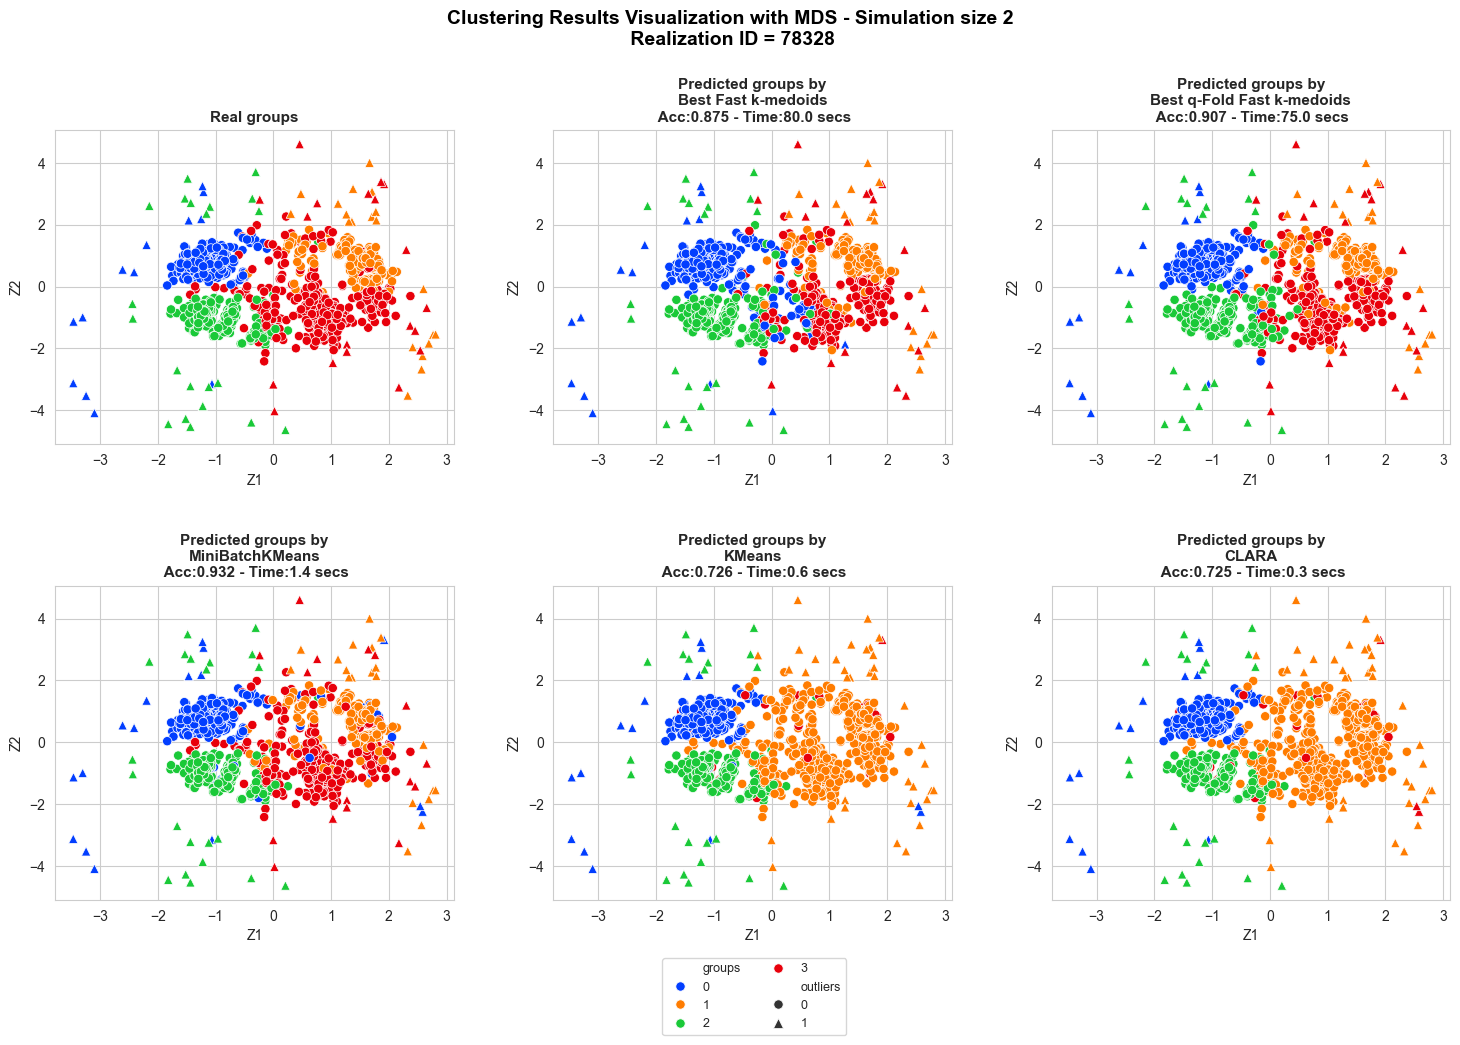

--------------------------------------------------
SIMULATION_SIZE_3
--------------------------------------------------


c:\Users\fscielzo\Documents\PhD\paper-2\paper-code\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


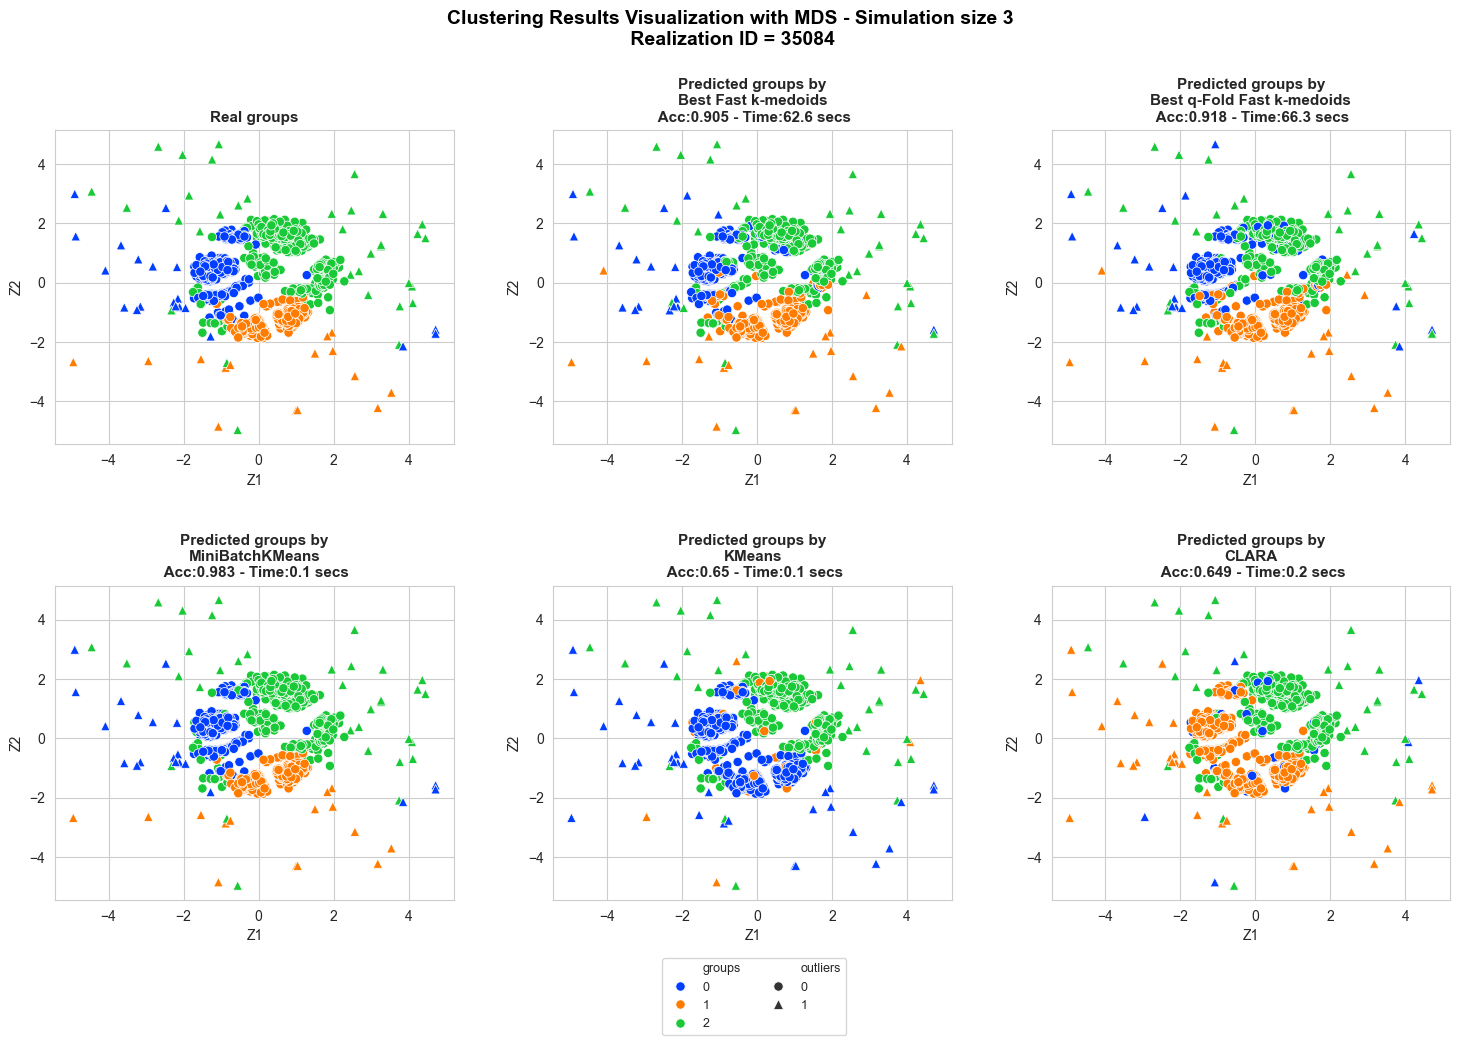

--------------------------------------------------
SIMULATION_SIZE_4
--------------------------------------------------


c:\Users\fscielzo\Documents\PhD\paper-2\paper-code\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


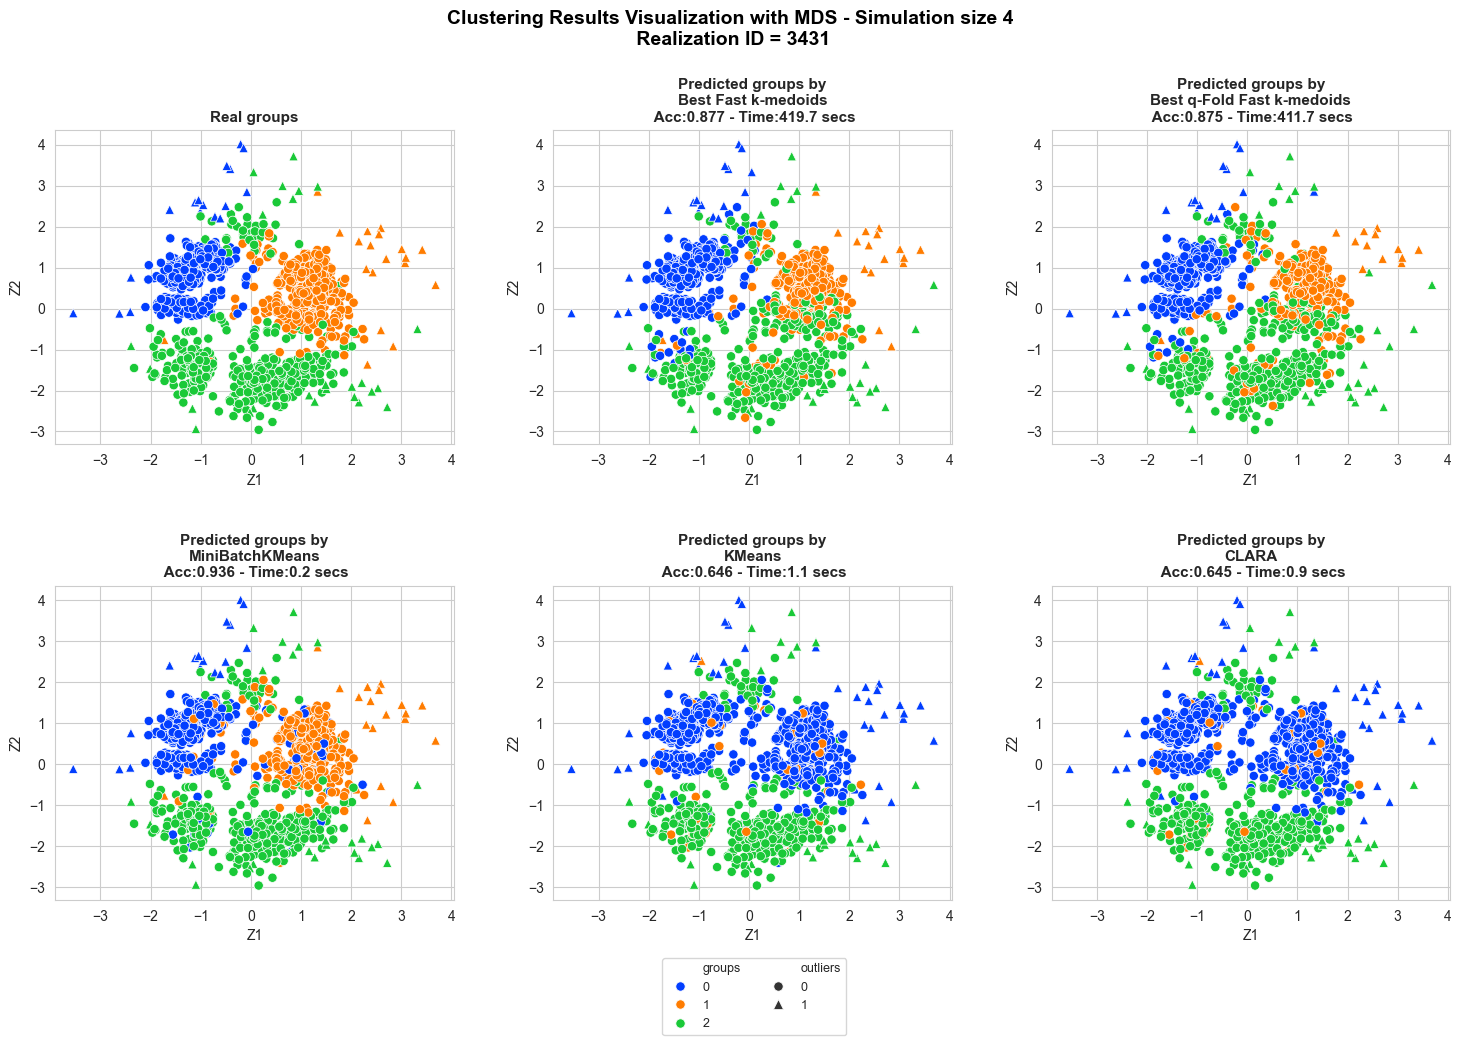

--------------------------------------------------
DUBAI_HOUSES
--------------------------------------------------


c:\Users\fscielzo\Documents\PhD\paper-2\paper-code\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


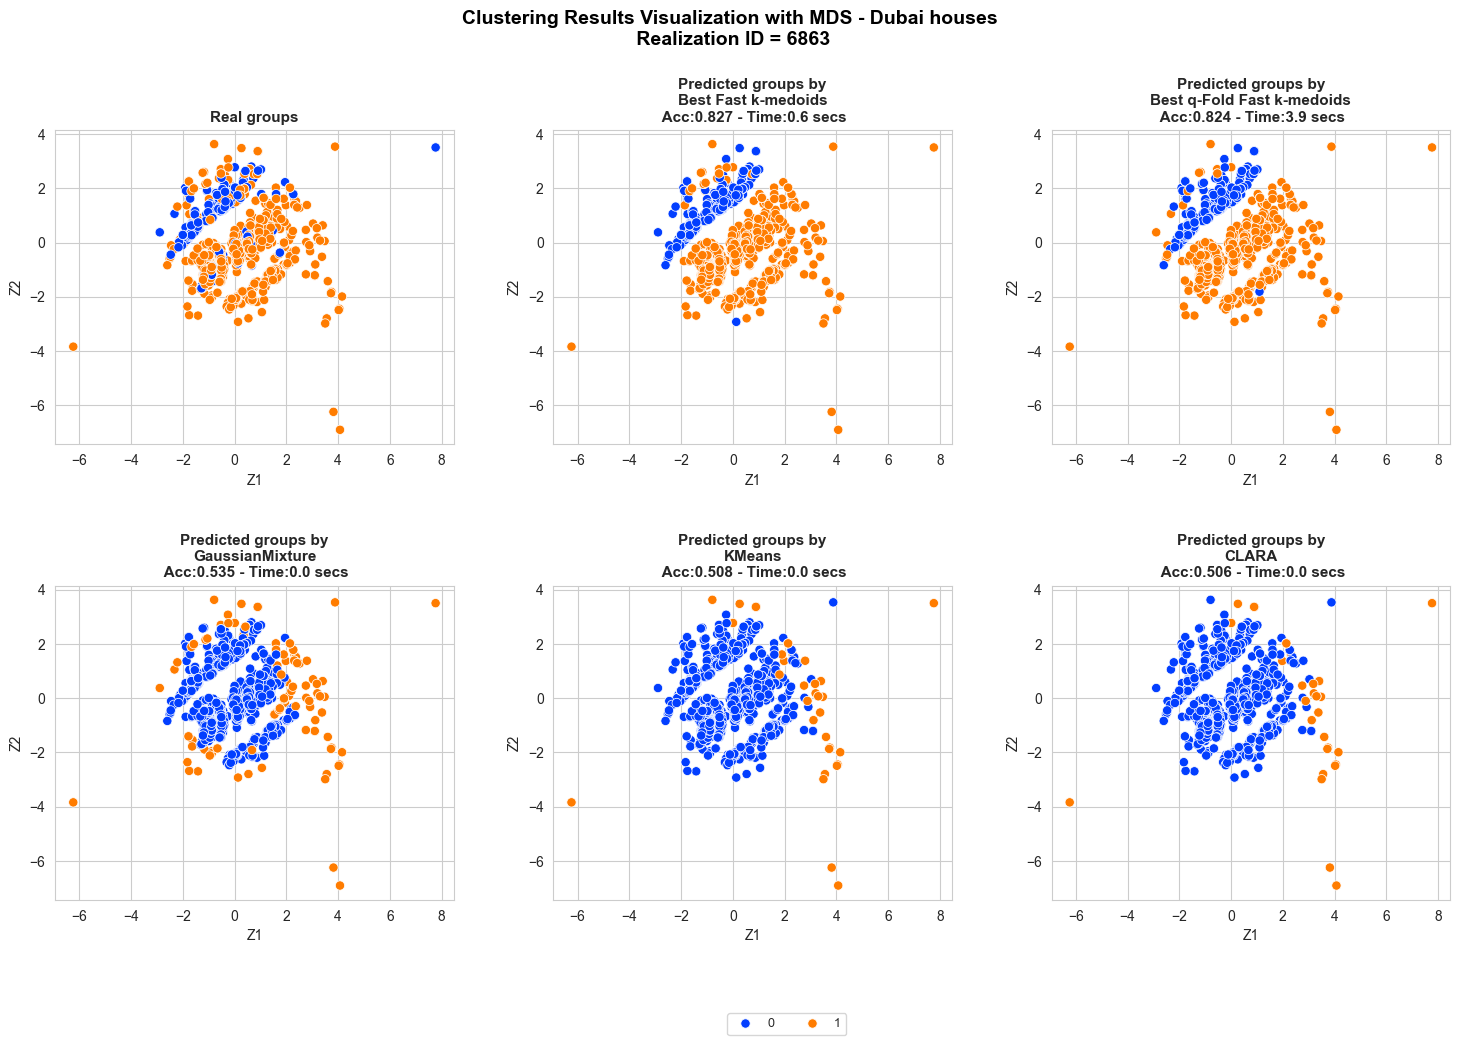

--------------------------------------------------
HEART_DISEASE
--------------------------------------------------


c:\Users\fscielzo\Documents\PhD\paper-2\paper-code\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


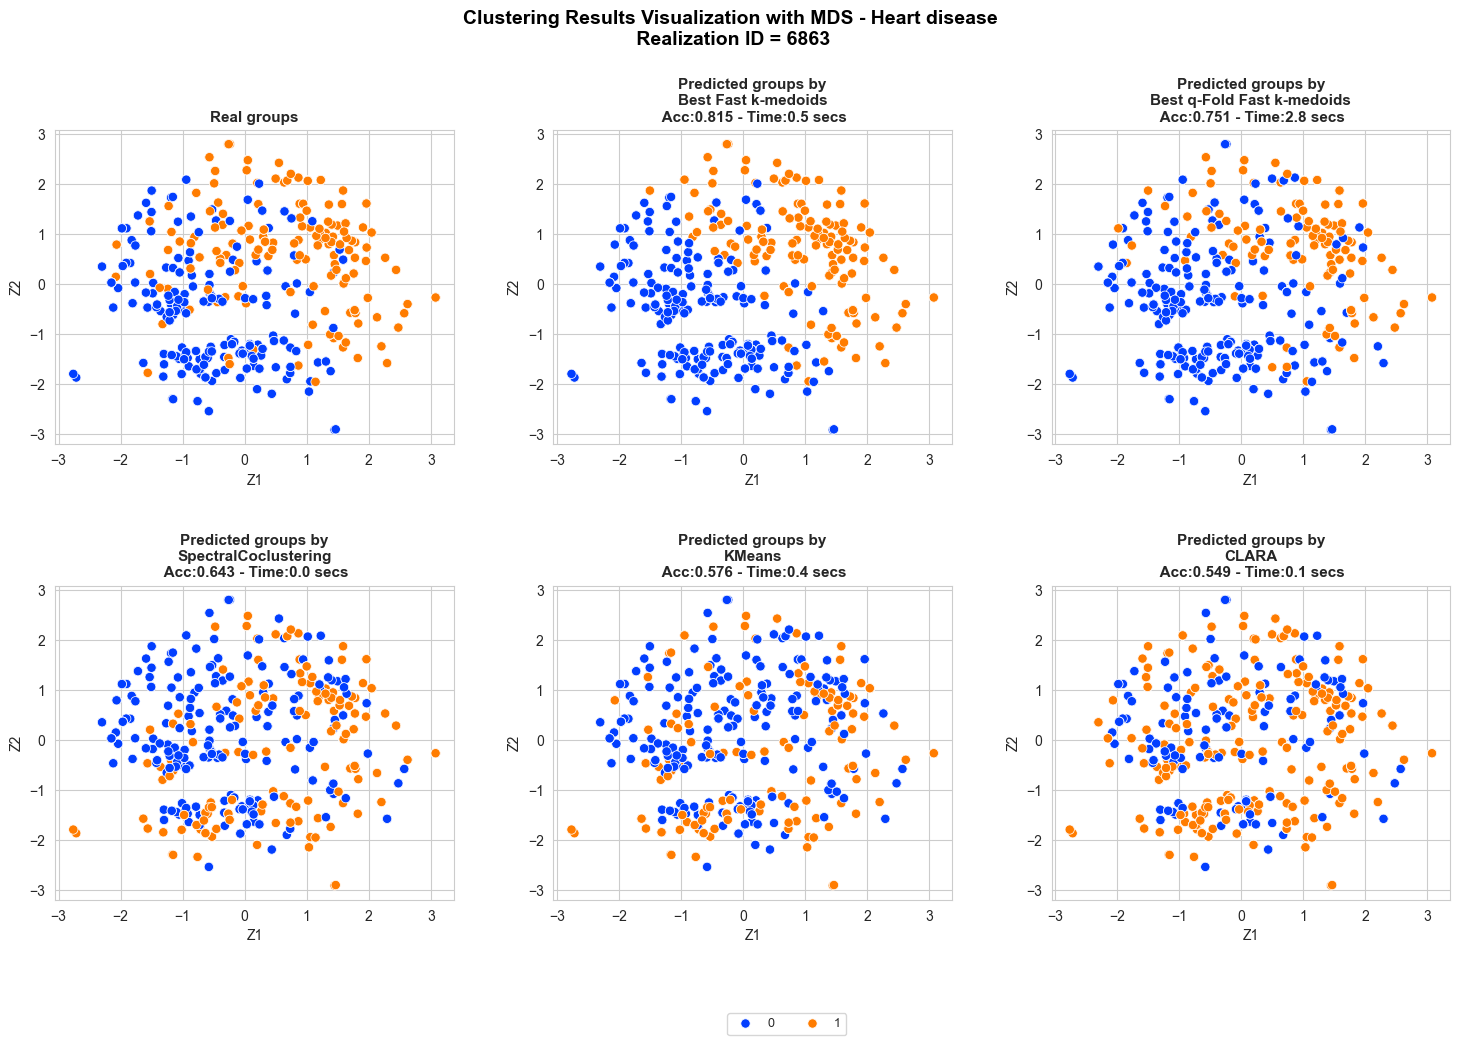

--------------------------------------------------
KC_HOUSES
--------------------------------------------------


c:\Users\fscielzo\Documents\PhD\paper-2\paper-code\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


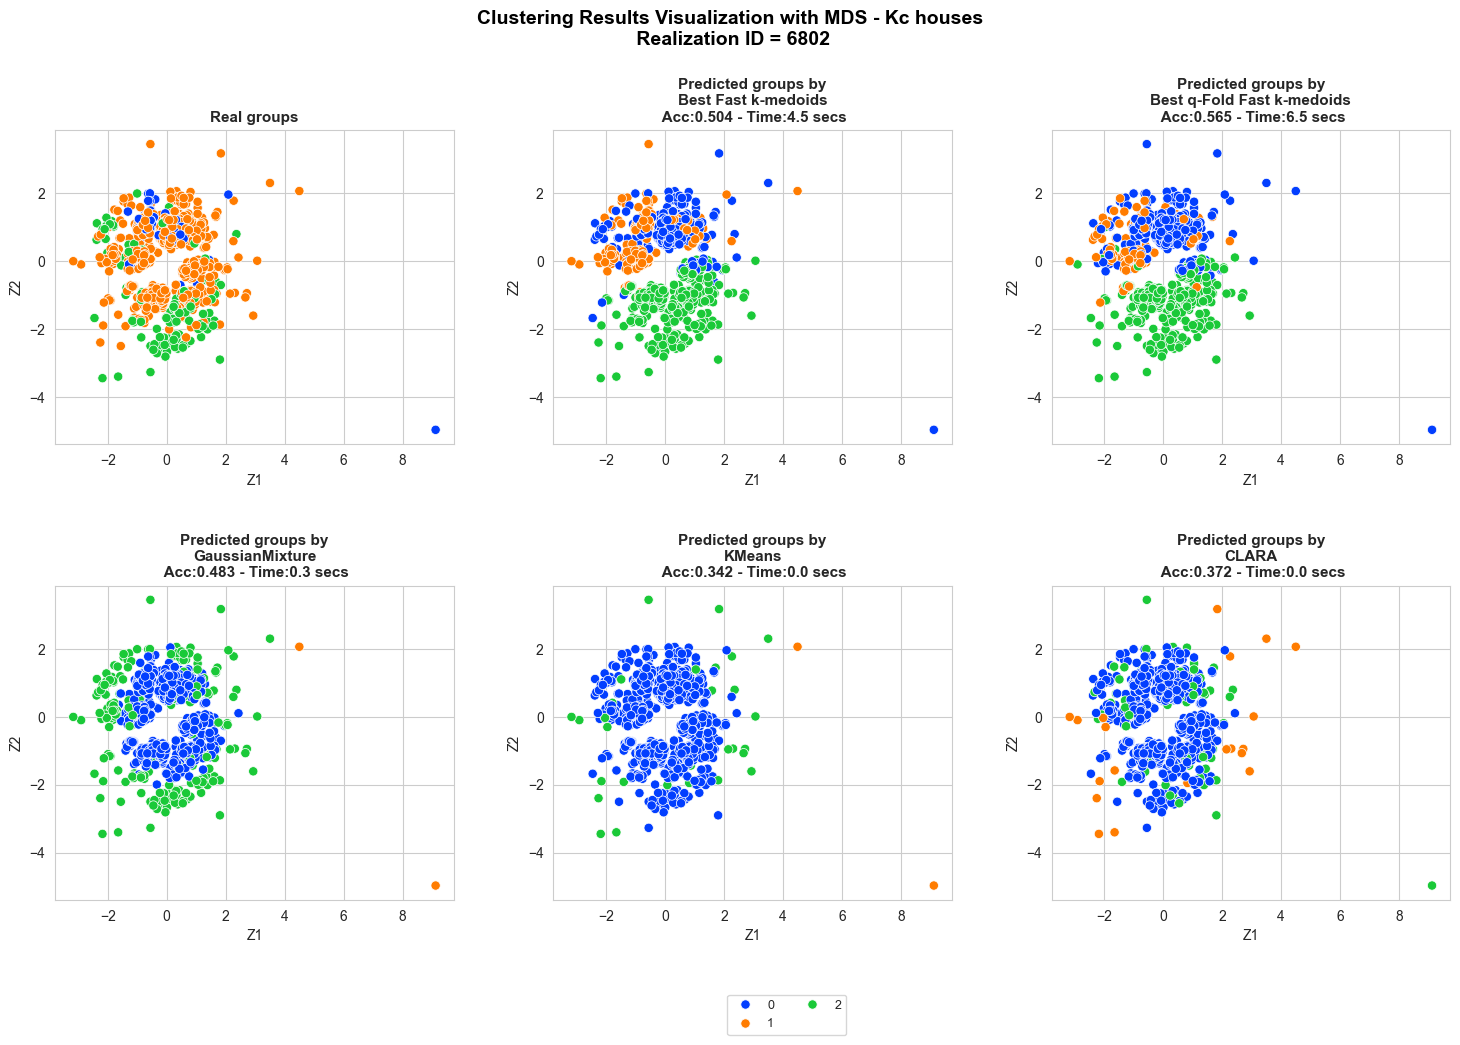

In [24]:
for data_id in DATA_IDS:

    print('-'*50)
    print(data_id.upper())
    print('-'*50)
   
    results = raw_results[data_id]
    df_avg = df_avg_results[data_id]
    config_experiment = CONFIG_EXPERIMENT[data_id]
    random_state_mds = RANDOM_STATE_MDS[data_id]  
    additional_methods = ADDITIONAL_METHODS_MDS[data_id]
    random_state_sample = 100

    d1 = 'robust_mahalanobis'
    d2 = 'sokal'
    d3 = 'hamming'
    robust_method = 'winsorized'

    if 'simulation' in data_id:

        simulation_config = SIMULATION_CONFIGS[data_id]

        X, y, outliers_idx = generate_simulation(
            random_state = random_state_mds,
            n_samples = simulation_config['n_samples'],
            centers = simulation_config['centers'],
            cluster_std = simulation_config['cluster_std'],
            n_features = simulation_config['n_features'],
            feature_types = simulation_config['feature_types'],
            outlier_configs = simulation_config['outlier_configs'],
            return_outlier_idx=True
        )

        outliers_bool = np.array([0 if x not in outliers_idx else 1 for x in range(0, len(X))])

    else:

        data_filename = f'{data_id}_processed.parquet'
        metadata_filename = f'metadata_{data_id}.json'
        processed_data_dir = os.path.join(project_path, 'data', 'processed_data')
        metadata_path = os.path.join(processed_data_dir, metadata_filename)
        processed_data_path = os.path.join(processed_data_dir, data_filename)
        with open(metadata_path, "r", encoding="utf-8") as f:
            metadata = json.load(f)
        data = pl.read_parquet(processed_data_path)
        X = data[metadata['quant_predictors'] + metadata['binary_predictors'] + metadata['multiclass_predictors']]
        y = data[metadata['response']]
        config_experiment.update({
            'p1': metadata['p1'],
            'p2': metadata['p2'],
            'p3': metadata['p3']
        })

    X_mds, sample_idx = fast_mds(
        sample_size=1400, 
        X=X, 
        d1=d1, d2=d2, d3=d3, robust_method=robust_method, 
        random_state_mds=random_state_mds, 
        random_state_sample=random_state_sample,
        config_experiment=config_experiment
    )

    not_feasible_methods = NOT_FEASIBLE_METHODS[data_id]
    model_names = df_avg['model_name'].unique().to_list()
    our_methods_1 = [x for x in model_names if 'Fast' in x and 'Fold' not in x] # Fast k-medoids
    our_methods_2 = [x for x in model_names if 'Fast' in x and 'Fold' in x] # q-Fold Fast k-medoids
    other_methods = [x for x in model_names if x not in our_methods_1 + our_methods_2 and x not in not_feasible_methods]
    sorted_methods_accuracy = df_avg['model_name'].to_list()
    our_methods_1_sorted_acc = [x for x in list(sorted_methods_accuracy) if x in our_methods_1]
    our_methods_2_sorted_acc = [x for x in list(sorted_methods_accuracy) if x in our_methods_2]
    other_methods_sorted_acc = [x for x in list(sorted_methods_accuracy) if x in other_methods]
    best_our_methods_1 = our_methods_1_sorted_acc[0]
    best_our_methods_2 = our_methods_2_sorted_acc[0]
    best_other_methods = other_methods_sorted_acc[0]

    methods_to_plot = [best_our_methods_1, best_our_methods_2, best_other_methods] + additional_methods
    names_to_plot = [('Best Fast k-medoids' if x in our_methods_1 else 'Best q-Fold Fast k-medoids' if x in our_methods_2 else x) for x in methods_to_plot]
    names_to_plot = dict(zip(methods_to_plot, names_to_plot))
    names_to_plot.update({'KMedoids-euclidean': 'KMedoids-pam'})
    y_pred_dict = {names_to_plot[method]: results[random_state_mds]['adj_labels'][method][sample_idx] for method in methods_to_plot}
    accuracy_dict = {names_to_plot[method]: results[random_state_mds]['adj_accuracy'][method] for method in methods_to_plot}
    time_dict = {names_to_plot[method]: results[random_state_mds]['time'][method] for method in methods_to_plot}

    plot_filename = f'mds_plot_results_exp_5_{data_id}.png'
    save_path = os.path.join(results_dir, plot_filename)
    formatted_data_name = data_id.replace('_', ' ').capitalize()

    clustering_MDS_plot_multiple_methods(X_mds=X_mds, y_pred=y_pred_dict, 
                                        y_true=y[sample_idx],
                                        title=f"Clustering Results Visualization with MDS - {formatted_data_name}\n Realization ID = {random_state_mds}", 
                                        accuracy=accuracy_dict, time=time_dict, n_rows=2,
                                        figsize=(18,10), bbox_to_anchor=(0.75,-1.9), 
                                        title_size=14, title_weight='bold', 
                                        subtitles_size=11,
                                        points_size=45, title_height=1, 
                                        wspace=0.25, hspace=0.45, 
                                        outliers_boolean=outliers_bool[sample_idx] if 'simulation' in data_id else None,
                                        n_cols_legend=2, legend_title='', legend_size=9, 
                                        save = True, file_name = save_path
)